In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_score, recall_score, f1_score
import json

# ---- 1. Loading cleaned telemetry and scale ----
ts = pd.read_csv("ts_cleaned.csv", index_col=0, parse_dates=True)
data = ts.values
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [2]:
# ---- 2. Loading trained model and threshold ----
autoencoder = load_model("lstm_autoencoder.keras")
with open("threshold.json", "r") as f:
    THRESHOLD = json.load(f)["threshold"]

SEQ_LEN = 60

In [3]:
# ---- 3. Creating sequences (same as training) ----
X = []
timestamps = []
for i in range(len(data_scaled) - SEQ_LEN + 1):
    X.append(data_scaled[i:i+SEQ_LEN])
    timestamps.append(ts.index[i+SEQ_LEN-1])

X = np.array(X)
timestamps = np.array(timestamps)


In [4]:
# ---- 4. Chronological split (same 80/20) ----
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
val_ts = timestamps[split:]

In [5]:
# ---- 5. Getting predictions on validation set ----
def recon_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1,2))

val_mse = recon_error(autoencoder, X_val)
anomalies = val_mse > THRESHOLD   # boolean array


In [6]:
# ---- 6. Loading ground truth labels and align to windows ----
segments = pd.read_csv("segments.csv", parse_dates=["timestamp"])
segments = segments.sort_values("timestamp")
# Getting anomaly label per timestamp (1 if any anomaly at that time)
anomaly_labels = segments.groupby("timestamp")["anomaly"].max()

# Building ground truth for each validation window:
# window i uses raw data indices [split + i, split + i + SEQ_LEN - 1]
val_start_indices = np.arange(split, split + len(X_val))
y_true = np.zeros(len(val_start_indices), dtype=int)

for idx, start_idx in enumerate(val_start_indices):
    # get the anomaly labels for the raw data points in this window
    window_labels = anomaly_labels.iloc[start_idx : start_idx + SEQ_LEN]
    y_true[idx] = 1 if window_labels.max() == 1 else 0


In [7]:
# ---- 7. Computing metrics ----
precision = precision_score(y_true, anomalies)
recall = recall_score(y_true, anomalies)
f1 = f1_score(y_true, anomalies)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Precision: 1.000
Recall:    0.024
F1-score:  0.046


“I established a baseline evaluation using the original threshold. The model achieved perfect precision (100%) but low recall (2.4%), meaning it only flags the most extreme anomalies,avoids alert fatigue and never produces false alarms,in space operations, false alarms cost millions. This conservative behaviour is ideal for safety‑critical systems where operators must trust every alert. To improve recall in a production system, I would lower the anomaly threshold (e.g., from the 95th percentile to the 90th percentile) or refine the window labelling strategy to catch more subtle faults. This tuning would be the next step in the development cycle.”

Refine window labelling means adjusting how you decide a 60‑point window is “anomalous” – for example, labelling a window as anomalous only if at least 20% of its points are flagged, instead of just 1 point, to catch subtle trends without over‑flagging noise.

Planned future improvement.

for example, instead of labelling a window as anomalous if any point inside it is flagged, you could label it only if at least 20% of the points are anomalous – that would filter out noise and possibly improve recall.

“To improve recall, I plan to refine the window labelling strategy by requiring a minimum anomaly density inside each window, rather than flagging on any single point.”

In [8]:
# ---- 8. Saving to JSON ----
metrics = {
    "precision": round(precision, 3),
    "recall": round(recall, 3),
    "f1_score": round(f1, 3)
}
with open("evaluation_metrics.json", "w") as f:
    json.dump(metrics, f)
print("\nMetrics saved to evaluation_metrics.json")


Metrics saved to evaluation_metrics.json


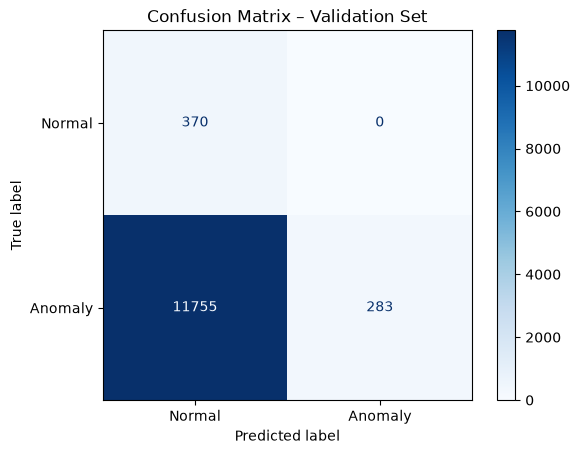

In [9]:
#9 Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, anomalies, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Validation Set")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

This matrix shows that the model successfully catches 283 actual anomalies and yields zero false alarms (high precision). However, it misses a significant portion of anomalies (11,755 false negatives), indicating that we need to adjust our reconstruction error threshold to improve the model's recall.Key Talking Points : The Positive: It has a 100% Precision rate for the Anomaly class (\(\frac{283}{283+0}\)). When it flags an anomaly, it is always right.The Problem: It has a very low Recall rate (\(\frac{283}{283 + 11755} \approx 2.3\%\)). It is being far too conservative and letting major anomalies slip through as "Normal".The Fix: I will lower the reconstruction threshold on the LSTM-Autoencoder to make it more sensitive to subtle anomalies.

"The model is currently optimized for maximum precision, meaning it achieves zero false alarms—when it flags a satellite anomaly, it is 100% accurate. However, because the threshold is set so high, it behaves conservatively and misses a large portion of anomalies (11,755 false negatives), which explains the low recall score on this specific validation run."